# Per-house TF-IDF word clouds

For each of the **top-12 largest houses** (by inferred member count), build one document = concatenation of every member's bio, run TF-IDF across the 12 documents, and render a word cloud per house. Same pattern as `Assignment2.ipynb`.

House labels use the §2.5 inference logic from `community_vs_region.ipynb` (Layer 0: walk the full allegiance list; Layer 1: single-hop family fallback) — **re-implemented inline, no CSV writes**.

In [11]:
import math
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

## 1. Load data and re-implement the §2.5 house inference

Same Layer 0 + Layer 1 logic as in `community_vs_region.ipynb` — kept inline so this notebook is self-contained and the persisted CSVs are untouched.

In [12]:
df = pd.read_csv('../csvs/characters_enriched.csv').fillna('')
bios_df = pd.read_csv('../csvs/characters_bio.csv').fillna('')
bios = dict(zip(bios_df['ID'], bios_df['bio']))

# Load quotes from characters_quotes.csv (one row per quote: name, ID, quote, speaker_id, recipient_id).
# Aggregate by speaker_id — every quote is attributed to whoever spoke it, regardless of which
# character's page it was scraped from.
import os
if os.path.exists('../csvs/characters_quotes.csv'):
    quotes_df = pd.read_csv('../csvs/characters_quotes.csv').fillna('')
    quotes_df = quotes_df[quotes_df['speaker_id'].str.len() > 0]
    quotes = quotes_df.groupby('speaker_id')['quote'].apply(lambda s: ' '.join(s)).to_dict()
    print(f'Loaded {len(quotes_df)} quotes attributed to {len(quotes)} distinct speakers')
else:
    quotes = {}
    print('characters_quotes.csv not found — running on bios only')

# Character-name filter: every token that appears in any character's display name
character_name_tokens = set()
for nm in df['name']:
    for part in str(nm).lower().split():
        cleaned = part.strip(string.punctuation)
        if cleaned and cleaned.isalpha() and len(cleaned) > 2:
            character_name_tokens.add(cleaned)
print(f'Character-name filter: {len(character_name_tokens)} tokens (e.g. {list(character_name_tokens)[:8]})')

REGION_TO_HOUSES = {
    'North': ['House_Stark', 'House_Bolton', 'House_Karstark', 'House_Manderly', 'House_Umber',
              'House_Mormont', 'House_Glover', 'House_Reed', 'House_Ryswell', 'House_Dustin',
              'House_Cerwyn', 'House_Hornwood', 'House_Tallhart', 'House_Flint', 'House_Cassel',
              'House_Ashwood', 'House_Locke', 'House_Magnar', 'House_Forrester', 'House_Stout',
              'House_Slate', 'House_Norrey', 'House_Wull', 'House_Liddle', 'House_Burley',
              'House_Harclay', 'House_Knott'],
    'Iron_Islands': ['House_Greyjoy', 'House_Harlaw', 'House_Drumm', 'House_Goodbrother',
                     'House_Saltcliffe', 'House_Stonehouse', 'House_Botley', 'House_Sparr',
                     'House_Wynch', 'House_Codd', 'House_Blacktyde', 'House_Sunderly',
                     'House_Tawney', 'House_Volmark', 'House_Merlyn', 'House_Ironmaker',
                     'House_Farwynd', 'House_Hoare'],
    'Riverlands': ['House_Tully', 'House_Frey', 'House_Bracken', 'House_Blackwood', 'House_Mallister',
                   'House_Mooton', 'House_Vance', 'House_Whent', 'House_Piper', 'House_Darry',
                   'House_Lothston', 'House_Charlton', 'House_Cox', 'House_Erenford', 'House_Goodbrook',
                   'House_Haigh', 'House_Lychester', 'House_Mudd', 'House_Ryger', 'House_Smallwood',
                   'House_Strong', 'House_Terrick', 'House_Paege', 'House_Roote', 'House_Shawney',
                   'House_Wode', 'House_Nayland'],
    'Vale': ['House_Arryn', 'House_Royce', 'House_Corbray', 'House_Waynwood', 'House_Hunter',
             'House_Templeton', 'House_Redfort', 'House_Belmore', 'House_Coldwater', 'House_Egen',
             'House_Grafton', 'House_Hardyng', 'House_Hersy', 'House_Lipps', 'House_Lynderly',
             'House_Melcolm', 'House_Pryor', 'House_Sunderland', 'House_Tollett', 'House_Upcliff',
             'House_Borrell', 'House_Baelish', 'House_Shett', 'House_Crayne'],
    'Westerlands': ['House_Lannister', 'House_Marbrand', 'House_Crakehall', 'House_Lefford', 'House_Brax',
                    'House_Banefort', 'House_Reyne', 'House_Tarbeck', 'House_Westerling', 'House_Spicer',
                    'House_Payne', 'House_Clegane', 'House_Algood', 'House_Bettley', 'House_Broom',
                    'House_Doggett', 'House_Estren', 'House_Falwell', 'House_Farman', 'House_Foote',
                    'House_Garner', 'House_Hetherspoon', 'House_Jast', 'House_Kyndall', 'House_Lannett',
                    'House_Lannister_of_Lannisport', 'House_Lorch', 'House_Lydden', 'House_Moreland',
                    'House_Myatt', 'House_Parren', 'House_Peckledon', 'House_Plumm', 'House_Prester',
                    'House_Ruttiger', 'House_Sarsfield', 'House_Serrett', 'House_Stackspear',
                    'House_Swyft', 'House_Turnberry', 'House_Vikary', 'House_Yew', 'House_Drox',
                    'House_Greenfield', 'House_Sarwyck'],
    'Reach': ['House_Tyrell', 'House_Hightower', 'House_Tarly', 'House_Florent', 'House_Rowan',
              'House_Redwyne', 'House_Oakheart', 'House_Fossoway', 'House_Ambrose', 'House_Chester',
              'House_Costayne', 'House_Beesbury', 'House_Caswell', 'House_Crane', 'House_Cuy',
              'House_Footly', 'House_Gardener', 'House_Graceford', 'House_Grimm', 'House_Hewett',
              'House_Inchfield', 'House_Kidwell', 'House_Leygood', 'House_Lowther', 'House_Lyberr',
              'House_Meadows', 'House_Merryweather', 'House_Mullendore', 'House_Norcross',
              'House_Norridge', 'House_Oldflowers', 'House_Orme', 'House_Osgrey', 'House_Peake',
              'House_Pommingham', 'House_Redding', 'House_Risley', 'House_Roxton', 'House_Serry',
              'House_Shermer', 'House_Sloane', 'House_Stackhouse', 'House_Uffering', 'House_Varner',
              'House_Vyrwel', 'House_Webber', 'House_Westbrook', 'House_Willum', 'House_Wythers',
              'House_Yelshire'],
    'Stormlands': ['House_Baratheon', 'House_Errol', 'House_Estermont', 'House_Penrose', 'House_Tarth',
                   'House_Connington', 'House_Caron', 'House_Dondarrion', 'House_Selmy', 'House_Swann',
                   'House_Wylde', 'House_Bolling', 'House_Buckler', 'House_Cafferen', 'House_Carter',
                   'House_Fell', 'House_Grandison', 'House_Hasty', 'House_Herston', 'House_Horpe',
                   'House_Kellington', 'House_Lonmouth', 'House_Mertyns', 'House_Morrigen', 'House_Musgood',
                   'House_Peasebury', 'House_Rogers', 'House_Seaworth', 'House_Staedmon', 'House_Trant',
                   'House_Wagstaff', 'House_Wensington', 'House_Whitehead', 'House_Toyne'],
    'Dorne': ['House_Martell', 'House_Yronwood', 'House_Dayne', 'House_Allyrion', 'House_Blackmont',
              'House_Fowler', 'House_Gargalen', 'House_Jordayne', 'House_Manwoody', 'House_Qorgyle',
              'House_Santagar', 'House_Toland', 'House_Uller', 'House_Vaith', 'House_Wyl', 'House_Briar',
              'House_Brook', 'House_Brownhill', 'House_Dalt', 'House_Drinkwater', 'House_Holt',
              'House_Hull', 'House_Lake', 'House_Ladybright', 'House_Sand', 'House_Shell', 'House_Wells'],
    'Crownlands': ['House_Targaryen', 'House_Velaryon', 'House_Celtigar', 'House_Massey', 'House_Rosby',
                   'House_Stokeworth', 'House_Buckwell', 'House_Crabb', 'House_Bar_Emmon', 'House_Brune',
                   'House_Byrch', 'House_Chyttering', 'House_Cressey', 'House_Darklyn', 'House_Edgerton',
                   'House_Farring', 'House_Gaunt', 'House_Hayford', 'House_Hogg', 'House_Langward',
                   'House_Longwaters', 'House_Mallery', 'House_Pyle', 'House_Rambton', 'House_Rollingford',
                   'House_Slynt', 'House_Staunton', 'House_Sunglass', 'House_Thorne', 'House_Wendwater',
                   'House_Blackfyre', 'Blacks', 'House_Baratheon_of_Dragonstone',
                   "House_Baratheon_of_King's_Landing"],
    'Beyond_the_Wall': ['Mance_Rayder', 'Stone_Crows', 'Free_Folk', 'Thenn', 'Frozen_Shore', 'Hornfoot_clan'],
    'Essos': ['Drogo', 'Faceless_Men', 'House_of_Loraq', 'Unsullied', 'House_Rogare', 'Volantis',
              'Lys', 'Pentos', 'Braavos', 'Sons_of_the_Harpy', 'Yunkai', 'Astapor', 'Meereen'],
    'Order': ['Citadel', "Night's_Watch", 'Faith_of_the_Seven', 'Kingsguard', 'Maesters', 'Sworn_Brothers'],
    'Sellsword': ['Golden_Company', 'Windblown', 'Second_Sons', 'Brave_Companions', 'Stormcrows',
                  'Company_of_the_Cat', 'Long_Lances', "Maiden's_Men"],
    'Outlaw': ['Brotherhood_without_banners', "Smiling_Knight's_band"],
}
HOUSE_TO_REGION = {h: region for region, hs in REGION_TO_HOUSES.items() for h in hs}

allegiance_lookup = dict(zip(df['ID'], df['allegiance']))
father_lookup     = dict(zip(df['ID'], df['father']))
mother_lookup     = dict(zip(df['ID'], df['mother']))
spouse_lookup     = dict(zip(df['ID'], df['spouse']))


def best_allegiance(allegiance_str):
    """Layer 0 — first listed allegiance that maps to a region wins."""
    if not allegiance_str:
        return ''
    for h in (a.strip() for a in allegiance_str.split(';')):
        if h in HOUSE_TO_REGION:
            return h
    return allegiance_str.split(';')[0].strip()


primary_house = {cid: best_allegiance(allegiance_lookup.get(cid, '')) for cid in df['ID']}

# Layer 1: family fallback (single-hop, father > mother > spouse)
def first_kin_house(cid):
    for col_lookup in [father_lookup, mother_lookup, spouse_lookup]:
        kin_str = col_lookup.get(cid, '')
        if not kin_str:
            continue
        for kin_id in kin_str.split(';'):
            kin_h = primary_house.get(kin_id.strip(), '')
            if kin_h in HOUSE_TO_REGION:
                return kin_h
    return ''

for cid in df['ID']:
    if primary_house.get(cid, '') not in HOUSE_TO_REGION:
        kin_h = first_kin_house(cid)
        if kin_h:
            primary_house[cid] = kin_h

mappable = sum(1 for h in primary_house.values() if h in HOUSE_TO_REGION)
print(f'Characters with a mappable house: {mappable}/{len(primary_house)}')

Loaded 4275 quotes attributed to 505 distinct speakers
Character-name filter: 3033 tokens (e.g. ['hosteen', 'gharak', 'jalabhar', 'redwyn', 'stygg', 'janna', 'colin', 'hunchbacked'])
Characters with a mappable house: 2711/3690


## 2. Pick the top-12 houses

Rank by inferred member count (Layer 0 + Layer 1).

In [13]:
house_counts = Counter(
    h for h in primary_house.values() if h in HOUSE_TO_REGION
)
top12_houses = [h for h, _ in house_counts.most_common(12)]
print('Top-12 houses by member count:')
for h, k in house_counts.most_common(12):
    print(f'  {k:>4}  {h}')

Top-12 houses by member count:
   158  Citadel
   137  House_Targaryen
   127  Night's_Watch
   117  House_Frey
   111  House_Stark
    78  Faith_of_the_Seven
    74  House_Lannister
    70  House_Greyjoy
    56  Mance_Rayder
    56  House_Tyrell
    52  House_Hightower
    51  House_Martell


## 3. Build per-house corpus and tokenize

Same tokenization as `Assignment2.ipynb`: lowercase, NLTK `word_tokenize`, drop English stopwords + punctuation. We additionally drop non-alphabetic tokens because bios contain a lot of dates / numerals / single-letter remnants from punctuation.

In [14]:
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.tokenize import MWETokenizer


def base_tokenize(text):
    """Lowercase + word_tokenize + filter stopwords/punct/non-alpha/character-names."""
    return [w for w in word_tokenize(text.lower())
            if w not in stop_words
            and w not in string.punctuation
            and w.isalpha()
            and w not in character_name_tokens]


# Discover collocations on the whole AWOIAF corpus (bio + quotes for every character).
# Mirrors course week 7: contingency-table + chi-squared scoring, then MWETokenizer
# merges significant bigrams into single tokens for the TF-IDF stage.
all_tokens = []
for cid in df['ID']:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    if text.strip():
        all_tokens.extend(base_tokenize(text))

bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(30)  # at least 30 occurrences
collocations = finder.nbest(bigram_measures.chi_sq, 100)
print(f'Found {len(collocations)} significant bigrams. Top 15:')
for w1, w2 in collocations[:15]:
    print(f'  {w1}_{w2}')

mwe = MWETokenizer(collocations, separator='_')


def tokenize(text):
    """base_tokenize + MWETokenizer to merge significant bigrams into single tokens."""
    return mwe.tokenize(base_tokenize(text))


house_tokens = {h: [] for h in top12_houses}
for cid, house in primary_house.items():
    if house in house_tokens:
        text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
        if text.strip():
            house_tokens[house].extend(tokenize(text))

for house in top12_houses:
    print(f'  {house:30s} {len(house_tokens[house]):>6} tokens')


Found 100 significant bigrams. Top 15:
  television_adaptation
  moat_cailin
  game_thrones
  casterly_rock
  vaes_dothrak
  deepwood_motte
  seastone_chair
  adaptation_game
  whispering_wood
  thrones_portrayed
  stony_shore
  haunted_forest
  valyrian_steel
  iron_throne
  brotherhood_banners
  Citadel                          8518 tokens
  House_Targaryen                 20994 tokens
  Night's_Watch                    8928 tokens
  House_Frey                       6372 tokens
  House_Stark                     23094 tokens
  Faith_of_the_Seven               5042 tokens
  House_Lannister                 19320 tokens
  House_Greyjoy                    8644 tokens
  Mance_Rayder                     4591 tokens
  House_Tyrell                     3569 tokens
  House_Hightower                  2663 tokens
  House_Martell                    6474 tokens


## 4. Compute TF, IDF, and TF-IDF

Each house = one document. IDF over the 12 documents — so a word that appears in every house gets IDF = 0 and drops out of every cloud (this naturally suppresses character/house surnames and ASOIAF-universe noise like *lord*, *ser*, *house* without a hand-built stoplist).

In [15]:
# TF: term frequency normalized by document length
tf_house = {}
for house, tokens in house_tokens.items():
    if not tokens:
        tf_house[house] = {}
        continue
    counts = Counter(tokens)
    total = len(tokens)
    tf_house[house] = {w: c / total for w, c in counts.items()}

# IDF: log(N / docs containing w), N = number of houses
N = len(house_tokens)
doc_freq = Counter()
for tokens in house_tokens.values():
    for w in set(tokens):
        doc_freq[w] += 1
idf = {w: math.log(N / doc_freq[w]) for w in doc_freq}

# TF-IDF
tfidf_house = {
    house: {w: tf * idf.get(w, 0) for w, tf in tf_vals.items()}
    for house, tf_vals in tf_house.items()
}

# Quick sanity print: top-10 TF-IDF terms for the largest house
biggest = top12_houses[0]
top10 = sorted(tfidf_house[biggest].items(), key=lambda x: x[1], reverse=True)[:10]
print(f'Top-10 TF-IDF terms for {biggest}:')
for w, s in top10:
    print(f'  {s:.5f}  {w}')

Top-10 TF-IDF terms for Citadel:
  0.00765  archmaester_citadel
  0.00532  archmaester
  0.00379  author
  0.00294  link
  0.00219  wrote
  0.00168  conclave
  0.00168  sphinx
  0.00167  book
  0.00147  links
  0.00146  ravenry


## 5. Word clouds — one per house

4 × 3 grid, ordered by member count (largest first).

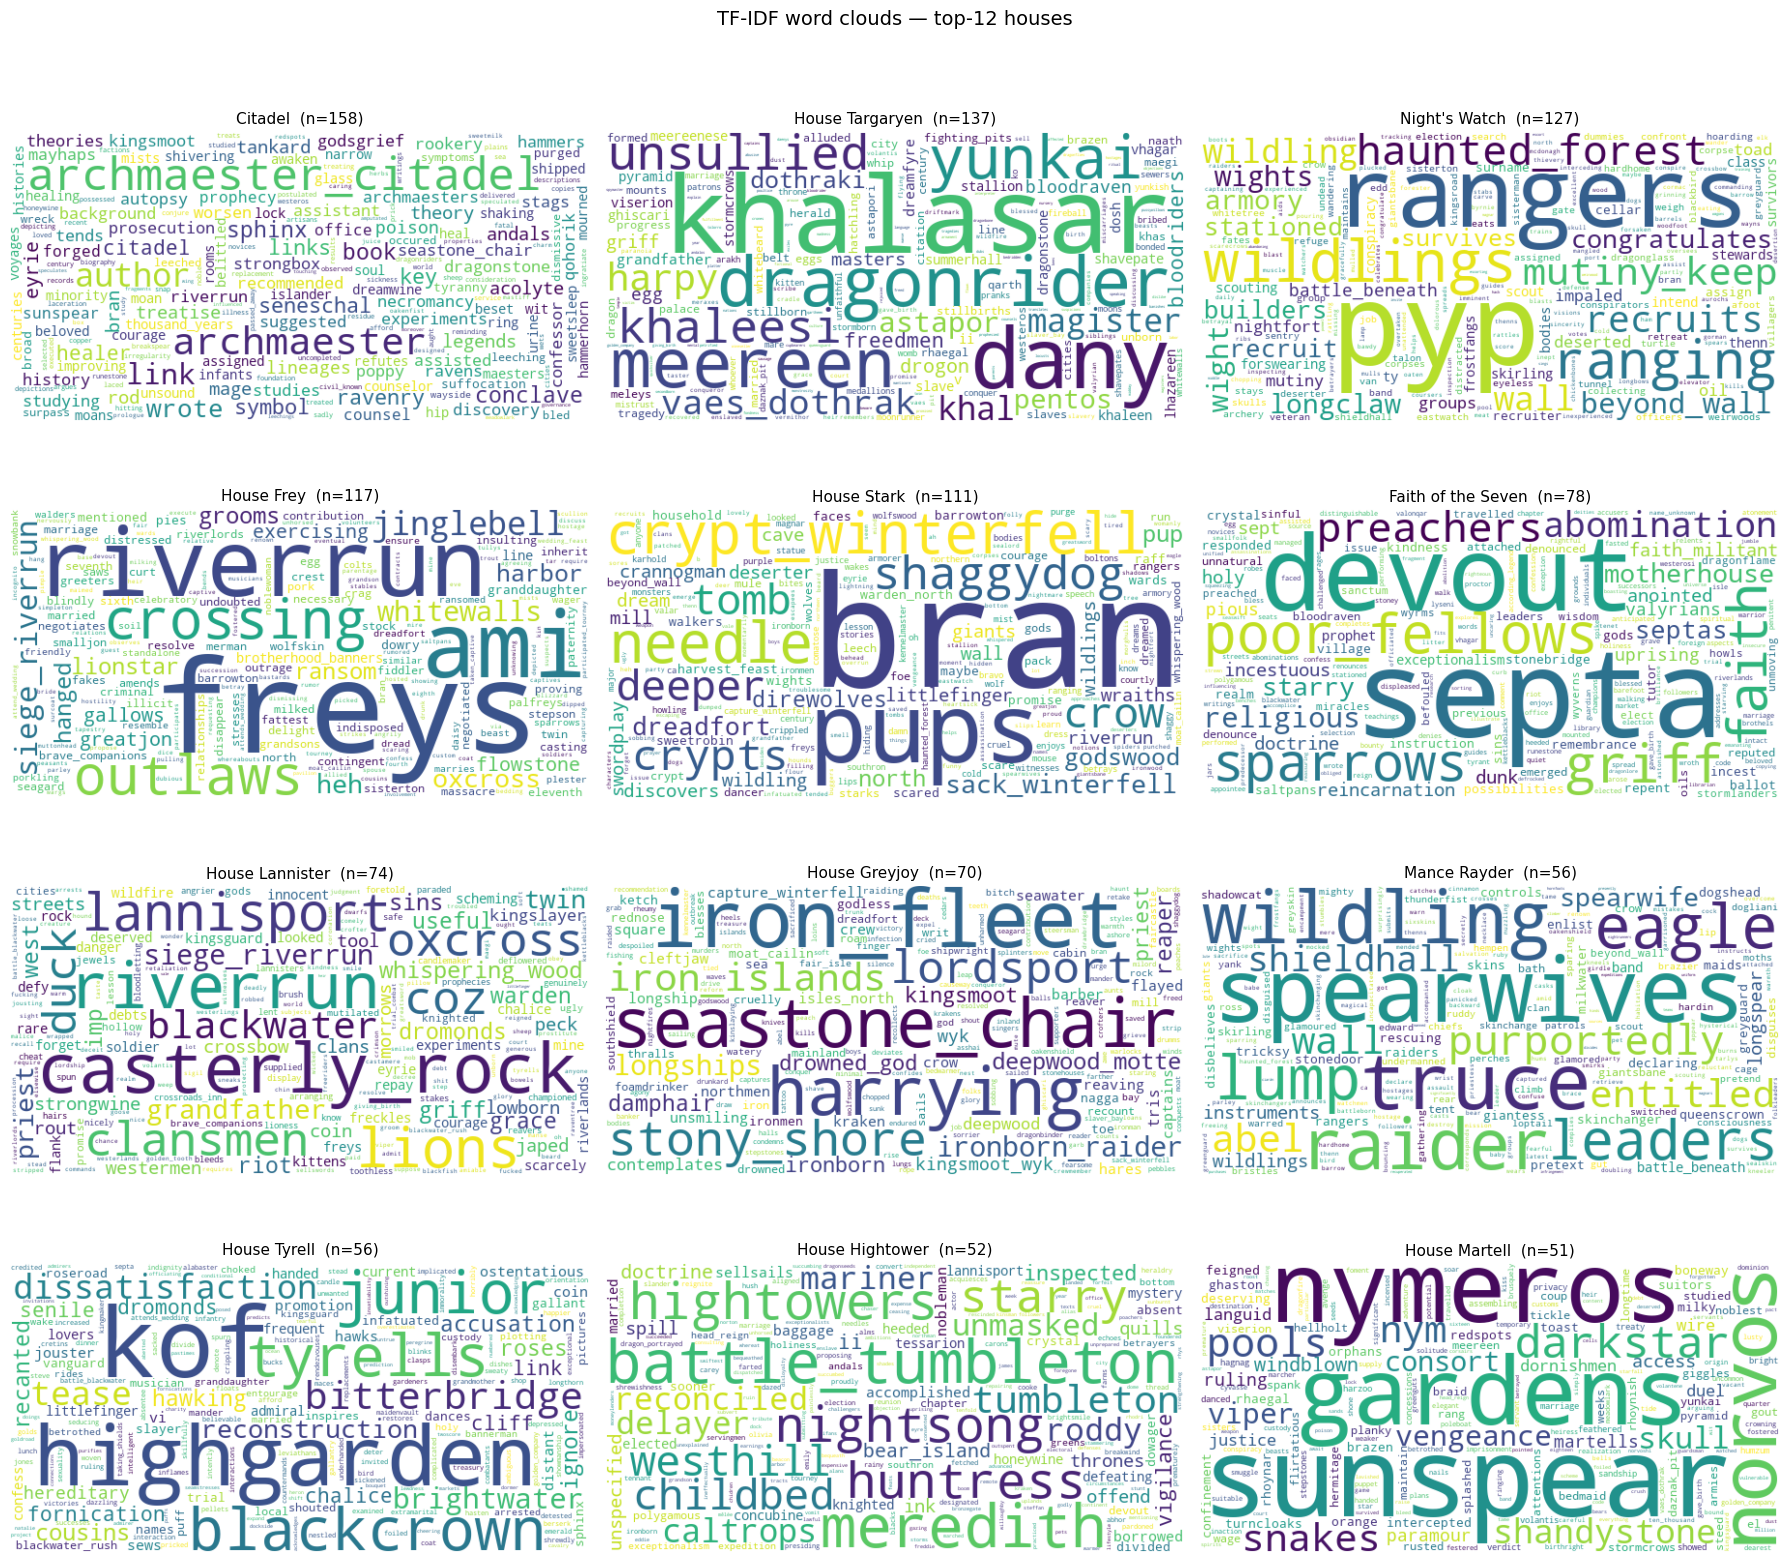

In [16]:
n_cols = 3
n_rows = math.ceil(len(top12_houses) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

for idx, house in enumerate(top12_houses):
    ax = axes_flat[idx]
    freqs = tfidf_house.get(house, {})
    if freqs:
        wc = WordCloud(width=600, height=300, background_color='white', colormap='viridis')
        ax.imshow(wc.generate_from_frequencies(freqs), interpolation='bilinear')
    else:
        ax.set_facecolor('#f4f4f4')
        ax.text(0.5, 0.5, 'No tokens', ha='center', va='center',
                fontsize=12, transform=ax.transAxes)
    ax.axis('off')
    title = f"{house.replace('_', ' ')}  (n={house_counts[house]})"
    ax.set_title(title, fontsize=11, pad=6)

for ax in axes_flat[len(top12_houses):]:
    ax.axis('off')

plt.suptitle(f'TF-IDF word clouds — top-{len(top12_houses)} houses', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()